In [2]:
!pip install watermark

In [58]:
!pip install torchinfo

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchinfo import summary
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import gzip
import pickle
import os

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [59]:
# Print versions using watermark
%reload_ext watermark
%watermark -v -m -p numpy,pandas,matplotlib,seaborn,torch,sklearn,transformers

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.34.0

numpy       : 1.26.4
pandas      : 2.2.3
matplotlib  : 3.7.5
seaborn     : 0.12.2
torch       : 2.5.1+cu121
sklearn     : 1.2.2
transformers: 4.47.0

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.6.56+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Dataset Preparation

In [61]:
!wget -O train.tsv "https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/train.tsv"
!wget -O test.tsv "https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/test.tsv"

--2025-03-15 16:29:40--  https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/train.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 720259 (703K) [text/plain]
Saving to: ‘train.tsv’

train.tsv           100%[===================>] 703.38K  --.-KB/s    in 0.05s   

2025-03-15 16:29:40 (12.7 MB/s) - ‘train.tsv’ saved [720259/720259]

--2025-03-15 16:29:40--  https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/test.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response...

In [79]:
# Load the dataset
train_df = pd.read_csv("train.tsv", delimiter="\t", header=None, names=["Review","Sentiment"])
test_df = pd.read_csv("test.tsv", delimiter="\t", header=None, names=["Review","Sentiment"])

In [80]:
# Load IMDB dataset
imdb_df = pd.read_csv("https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv")
imdb_df["sentiment"] = imdb_df["sentiment"].map({"positive": 1, "negative": 0})

In [43]:
train_df.sample(5)

,Review,Sentiment
6887,it 's supposed to be post feminist breezy but ...,0
6771,execrable,0
5925,"forget the misleading title , what 's with the...",0
687,a must see for fans of thoughtful war films an...,1
3424,this is an undeniably intriguing film from an ...,1


In [81]:
X_train = train_df['Review']
y_train = train_df['Sentiment']
X_test = test_df['Review']
y_test = test_df['Sentiment']

In [82]:
# Split training data into train and validation (80-20 split)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [83]:
print(f"Shape of training data: {X_train.shape}")
print(f"Shape of validation data: {X_val.shape}")
print(f"Shape of testing data: {X_test.shape}")

Shape of training data: (5536,)
Shape of validation data: (1384,)
Shape of testing data: (1821,)


## Construct a Multi-Layer Perceptron (MLP) model.

In [84]:
class MLPModel(nn.Module):
    def __init__(self, input_size=10000, hidden_sizes=[512, 256, 128, 64], output_size=2):
        super(MLPModel, self).__init__()

        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.fc4 = nn.Linear(hidden_sizes[2], hidden_sizes[3])
        self.fc5 = nn.Linear(hidden_sizes[3], output_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)  # Dropout for regularization

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.dropout(self.relu(self.fc3(x)))
        x = self.dropout(self.relu(self.fc4(x)))
        x = self.fc5(x)
        return x


In [85]:
# Initialize Model
model = MLPModel()

# Print Summary (batch_size=1, input_size=10000)
summary(model, input_size=(1, 10000), col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
MLPModel                                 [1, 10000]                [1, 2]                    --                        True
├─Linear: 1-1                            [1, 10000]                [1, 512]                  5,120,512                 True
├─ReLU: 1-2                              [1, 512]                  [1, 512]                  --                        --
├─Dropout: 1-3                           [1, 512]                  [1, 512]                  --                        --
├─Linear: 1-4                            [1, 512]                  [1, 256]                  131,328                   True
├─ReLU: 1-5                              [1, 256]                  [1, 256]                  --                        --
├─Dropout: 1-6                           [1, 256]                  [1, 256]                  --                        --
├─Linear: 1

## Implement case 1: Bag-of-words

In [86]:
vectorizer = CountVectorizer(max_features=10000)
X_train_bow = vectorizer.fit_transform(X_train).toarray()
X_val_bow = vectorizer.transform(X_val).toarray()
X_test_bow = vectorizer.transform(X_test).toarray()

##  Implement case 2: Construct a function to use LLaMa-3.1 embeddings on the same model.

In [19]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("hf_token")

login(token=hf_token)

In [ ]:
class LLaMaEmbedding:
    def __init__(self, model_name="meta-llama/Llama-3.1-8B"):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")

        # Load tokenizer
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token  # Set padding token

        # Load model with FP16 for memory efficiency
        self.model = AutoModel.from_pretrained(model_name, torch_dtype=torch.float16).to(self.device)

        # Store embedding size
        self.embedding_size = self.model.config.hidden_size

    def get_embedding(self, text):
        inputs = self.tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512).to(self.device)
        
        with torch.no_grad():
            outputs = self.model(**inputs)

        return outputs.last_hidden_state.mean(dim=1).squeeze(0).cpu().numpy() # Convert to NumPy

def process_in_batches(texts, embedder, batch_size=16):
    """Processes text data in batches to avoid memory overload."""
    embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i : i + batch_size]
        batch_embeddings = [embedder.get_embedding(text) for text in batch_texts]
        embeddings.extend(batch_embeddings)  # Store results

        torch.cuda.empty_cache()  # Free GPU memory

    return np.array(embeddings)  # Convert list to NumPy array

In [ ]:
# Initialize LLaMa embedder
llama_embedder = LLaMaEmbedding()

In [ ]:
# Compute embeddings
X_train_llama = process_in_batches(X_train, llama_embedder)
X_val_llama = process_in_batches(X_val, llama_embedder)
X_test_llama = process_in_batches(X_test, llama_embedder)

In [ ]:
# Here we saved the Embeddings (as it takes time to compute them each time)
# We have made a dataset which has all the embeddings and link of it has been provided in the pdf
# The embeddings were generated in another kaggle notebook and then directly used in this notebook as we were facing issues of CUDA Memory Limit
# The code for generating the embeddings has been provided in this notebook

save_path = "/kaggle/working/"

# Save embeddings
np.save(save_path + "X_train_llama.npy", X_train_llama)
np.save(save_path + "X_val_llama.npy", X_val_llama)
np.save(save_path + "X_test_llama.npy", X_test_llama)

print(f"Embeddings saved in {save_path}")

In [87]:
# So we can downlaod the embeddings from the link and just add the path of that dataset below

# Loading previously saved embeddings
X_train_llama = np.load("/kaggle/input/X_train_llama.npy")
X_val_llama = np.load("/kaggle/input/X_val_llama.npy")
X_test_llama = np.load("/kaggle/input/X_test_llama.npy")

In [88]:
X_train_bow.shape

(5536, 10000)

In [89]:
X_train_llama.shape

(5536, 4096)

In [90]:
# Convert labels to NumPy arrays before converting to PyTorch tensors
y_train = torch.tensor(y_train.to_numpy(), dtype=torch.long)
y_val = torch.tensor(y_val.to_numpy(), dtype=torch.long)
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.long)

In [91]:
# Hyperparameters
HYPERPARAMS = {
    "input_size": 10000, 
    "hidden_sizes": [512, 256, 128, 64],  
    "output_size": 2,  
    "epochs": 10,
    "batch_size": 32,
    "learning_rate": 0.0001
}

In [92]:
import os

def save_compressed_checkpoint(checkpoint, checkpoint_path):
    
    compressed_checkpoint_path = checkpoint_path + ".gz"
    temp_checkpoint_file = checkpoint_path + ".pt"  # Save as .pt file first

    # Save checkpoint as a .pt file first
    with open(temp_checkpoint_file, "wb") as f:
        pickle.dump(checkpoint, f, protocol=pickle.HIGHEST_PROTOCOL)

    # Compress the .pt file into a .gz archive
    with open(temp_checkpoint_file, "rb") as f_in:
        with gzip.open(compressed_checkpoint_path, "wb") as f_out:
            f_out.writelines(f_in)

    
    os.remove(temp_checkpoint_file)

    print(f"Compressed checkpoint saved at: {compressed_checkpoint_path}")


In [93]:
def train_model(model, X_train, y_train, X_val, y_val, checkpoint_path, model_type):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=HYPERPARAMS["learning_rate"])
    criterion = torch.nn.CrossEntropyLoss()

    torch.cuda.empty_cache()  # Free up memory

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)),
        batch_size=HYPERPARAMS["batch_size"], shuffle=True, pin_memory=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long)),
        batch_size=HYPERPARAMS["batch_size"], shuffle=False, pin_memory=True
    )

    # Separate TensorBoard logs for BoW and LLaMa
    writer = SummaryWriter(log_dir=f"runs/{model_type}")  

    best_val_acc = 0.0
    best_model_state = None
    best_optimizer_state = None
    best_loss = None

    for epoch in range(HYPERPARAMS["epochs"]):
        model.train()
        total_train_loss = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        # Log model parameters (weights & biases)
        for name, param in model.named_parameters():
            writer.add_histogram(f"Parameters/{name}", param.clone().cpu().data.numpy(), epoch)

        # Validation
        model.eval()
        total_val_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)

                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                total_val_loss += loss.item()

                preds = torch.argmax(outputs, axis=1)
                val_correct += (preds == batch_y).sum().item()
                val_total += batch_y.size(0)

        val_acc = val_correct / val_total
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)

        # Log to TensorBoard
        writer.add_scalar("Loss/train", avg_train_loss, epoch)
        writer.add_scalar("Loss/val", avg_val_loss, epoch)
        writer.add_scalar("Accuracy/val", val_acc, epoch)

        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}, Val Accuracy = {val_acc:.4f}")

        # Save only the best checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            best_optimizer_state = optimizer.state_dict().copy()

    # Save the final best model in compressed format
    if best_model_state:
        checkpoint = {
            "model_state_dict": best_model_state,
            "optimizer_state_dict": best_optimizer_state,
            "hyperparameters": HYPERPARAMS,
            "performance": {
                "final_loss": best_loss,
                "final_accuracy": best_val_acc
            }
        }
        save_compressed_checkpoint(checkpoint, checkpoint_path)
        print(f"Best model saved with Validation Accuracy: {best_val_acc:.4f}")

    writer.close()
    return model

In [94]:
# Initialize model
model_bow = MLPModel(input_size=10000)

# Train the model
trained_model_bow = train_model(model_bow, X_train_bow, y_train, X_val_bow, y_val, checkpoint_path="mlp_bow", model_type="bow")

Epoch 1: Train Loss = 0.6917, Val Loss = 0.6896, Val Accuracy = 0.5152
Epoch 2: Train Loss = 0.6074, Val Loss = 0.4816, Val Accuracy = 0.7890
Epoch 3: Train Loss = 0.3045, Val Loss = 0.4525, Val Accuracy = 0.8049
Epoch 4: Train Loss = 0.1319, Val Loss = 0.5480, Val Accuracy = 0.7991
Epoch 5: Train Loss = 0.0604, Val Loss = 0.6543, Val Accuracy = 0.7955
Epoch 6: Train Loss = 0.0312, Val Loss = 0.7662, Val Accuracy = 0.7962
Epoch 7: Train Loss = 0.0177, Val Loss = 0.9278, Val Accuracy = 0.7984
Epoch 8: Train Loss = 0.0103, Val Loss = 0.9484, Val Accuracy = 0.8020
Epoch 9: Train Loss = 0.0056, Val Loss = 1.0561, Val Accuracy = 0.7977
Epoch 10: Train Loss = 0.0040, Val Loss = 1.1485, Val Accuracy = 0.7955
Compressed checkpoint saved at: mlp_bow.gz
Best model saved with Validation Accuracy: 0.8049


In [95]:
# Initialize model
model_llama = MLPModel(input_size=X_train_llama.shape[1])

# Train the model
trained_model_llama = train_model(model_llama, X_train_llama, y_train, X_val_llama, y_val, checkpoint_path="mlp_llama", model_type="llama")

Epoch 1: Train Loss = 0.4950, Val Loss = 0.3412, Val Accuracy = 0.8475
Epoch 2: Train Loss = 0.3330, Val Loss = 0.3137, Val Accuracy = 0.8728
Epoch 3: Train Loss = 0.2950, Val Loss = 0.2929, Val Accuracy = 0.8801
Epoch 4: Train Loss = 0.2643, Val Loss = 0.2675, Val Accuracy = 0.8931
Epoch 5: Train Loss = 0.2473, Val Loss = 0.2523, Val Accuracy = 0.8952
Epoch 6: Train Loss = 0.2195, Val Loss = 0.2637, Val Accuracy = 0.9017
Epoch 7: Train Loss = 0.2109, Val Loss = 0.2749, Val Accuracy = 0.8923
Epoch 8: Train Loss = 0.1912, Val Loss = 0.2682, Val Accuracy = 0.8988
Epoch 9: Train Loss = 0.1687, Val Loss = 0.2597, Val Accuracy = 0.9053
Epoch 10: Train Loss = 0.1732, Val Loss = 0.2557, Val Accuracy = 0.9068
Compressed checkpoint saved at: mlp_llama.gz
Best model saved with Validation Accuracy: 0.9068


Confusion Matrix - BoW Model - Test Accuracy: 0.7941


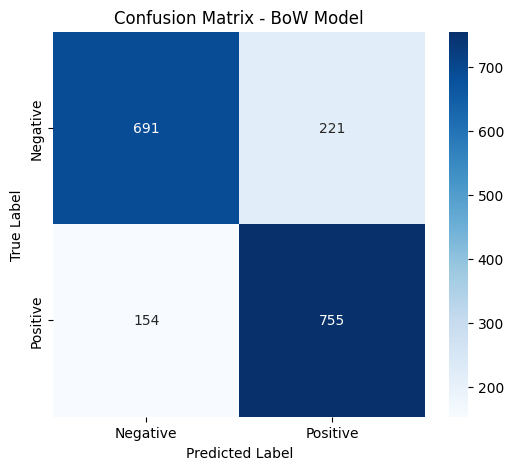

Confusion Matrix - LLaMa Model - Test Accuracy: 0.9132


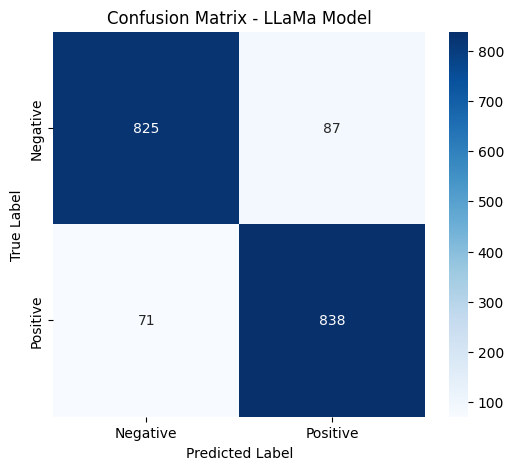

In [96]:
def predict(model, X):
    model.eval()  # Set to evaluation mode
    device = next(model.parameters()).device  # Get model's device
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)  # Move input data to same device
    
    with torch.no_grad():
        outputs = model(X_tensor)
        predictions = torch.argmax(outputs, axis=1)  # Get predicted class labels
    return predictions.cpu().numpy()  # Move back to CPU for sklearn

def plot_confusion_matrix(model, X, y_true, title="Confusion Matrix"):
    y_pred = predict(model, X)
    
    # Compute confusion matrix and accuracy
    cm = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    
    # Print accuracy
    print(f"{title} - Test Accuracy: {accuracy:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

# Evaluate and plot for both models
plot_confusion_matrix(trained_model_bow, X_test_bow, y_test, title="Confusion Matrix - BoW Model")
plot_confusion_matrix(trained_model_llama, X_test_llama, y_test, title="Confusion Matrix - LLaMa Model")


Confusion Matrix - IMDB BoW Model - Test Accuracy: 0.7733


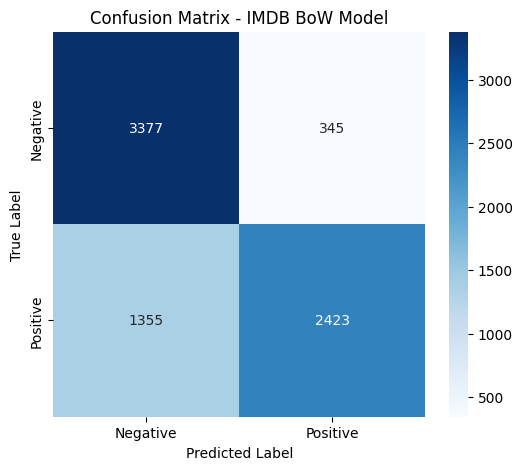

Confusion Matrix - IMDB LLaMa Model - Test Accuracy: 0.9172


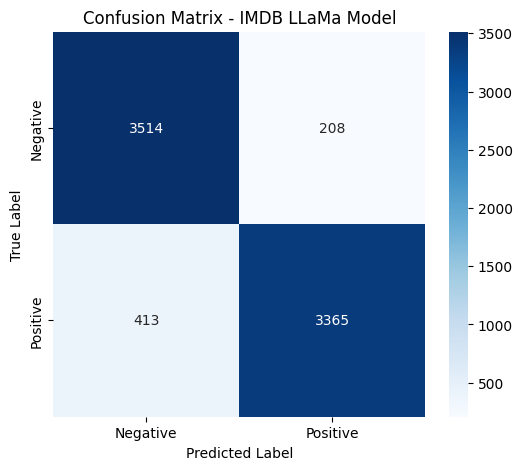

In [97]:
plot_confusion_matrix(trained_model_bow,  X_test_imdb_bow, y_test_imdb, title="Confusion Matrix - IMDB BoW Model")
plot_confusion_matrix(trained_model_llama,X_test_imdb_llama, y_test_imdb, title="Confusion Matrix - IMDB LLaMa Model")


In [98]:
import pickle

def load_compressed_checkpoint(checkpoint_path, model, device="cpu"):
    with gzip.open(checkpoint_path, "rb") as f:
        checkpoint = pickle.load(f)

    model.load_state_dict(checkpoint["model_state_dict"],strict=False)
    model.to(device)  # Move model to the specified device
    
    print(f"Model loaded from: {checkpoint_path}")
    print(f"Hyperparameters: {checkpoint['hyperparameters']}")
    print(f"Final Accuracy Before Resume: {checkpoint['performance']['final_accuracy']:.4f}\n")

    return model

In [99]:
# Initialize empty model structures
model_bow_z = MLPModel()
model_llama_z = MLPModel(input_size=X_train_llama.shape[1])

# Load saved models from compressed checkpoints
model_bow_z = load_compressed_checkpoint("mlp_bow.gz", model_bow)
model_llama_z = load_compressed_checkpoint("mlp_llama.gz", model_llama)

# Move models to device
device = "cuda" if torch.cuda.is_available() else "cpu"
model_bow_z.to(device)
model_llama_z.to(device)

print("Checkpoint models loaded successfully and ready for further training!")


Model loaded from: mlp_bow.gz
Hyperparameters: {'input_size': 10000, 'hidden_sizes': [512, 256, 128, 64], 'output_size': 2, 'epochs': 10, 'batch_size': 32, 'learning_rate': 0.0001}
Final Accuracy Before Resume: 0.8049

Model loaded from: mlp_llama.gz
Hyperparameters: {'input_size': 10000, 'hidden_sizes': [512, 256, 128, 64], 'output_size': 2, 'epochs': 10, 'batch_size': 32, 'learning_rate': 0.0001}
Final Accuracy Before Resume: 0.9068

Checkpoint models loaded successfully and ready for further training!


## Continual training on IMDB dataset

In [100]:
# Extract IMDB reviews and labels
X_imdb = imdb_df["review"].tolist()
y_imdb = torch.tensor(imdb_df["sentiment"].values, dtype=torch.long)

# Split into training (70%), validation (15%), and test (15%)
X_train_imdb, X_temp_imdb, y_train_imdb, y_temp_imdb = train_test_split(X_imdb, y_imdb, test_size=0.3, random_state=42)
X_val_imdb, X_test_imdb, y_val_imdb, y_test_imdb = train_test_split(X_temp_imdb, y_temp_imdb, test_size=0.5, random_state=42)

In [101]:
# Process BoW features
X_train_imdb_bow = vectorizer.transform(X_train_imdb).toarray()
X_val_imdb_bow = vectorizer.transform(X_val_imdb).toarray()
X_test_imdb_bow = vectorizer.transform(X_test_imdb).toarray()

In [ ]:
# Process LLaMa embeddings
X_train_imdb_llama = process_in_batches(X_train_imdb, llama_embedder)
X_val_imdb_llama = process_in_batches(X_val_imdb, llama_embedder)
X_test_imdb_llama = process_in_batches(X_test_imdb, llama_embedder)

In [ ]:
save_path = "/kaggle/working/"

np.save(save_path + "X_train_imdb_llama.npy", X_train_imdb_llama)
np.save(save_path + "X_val_imdb_llama.npy", X_val_imdb_llama)
np.save(save_path + "X_test_imdb_llama.npy", X_test_imdb_llama)


print("LLaMa embeddings saved successfully!")

In [102]:
X_train_imdb_llama = np.load("/kaggle/input/X_train_imdb_llama.npy")
X_val_imdb_llama = np.load("/kaggle/input/X_val_imdb_llama.npy")
X_test_imdb_llama = np.load("/kaggle/input/X_test_imdb_llama.npy")

print("LLaMa embeddings loaded successfully!")

LLaMa embeddings loaded successfully!


In [104]:
def resume_training(model, X_train, y_train, X_val, y_val, checkpoint_path, model_type):
    print(f"Resuming training with {checkpoint_path} on IMDB dataset...")

    # Resume training with IMDB dataset using train_model()
    return train_model(model, X_train, y_train, X_val, y_val, checkpoint_path=f"{checkpoint_path}_imdb", model_type=model_type)

In [111]:
trained_model_bow_imdb = resume_training(model_bow_z, X_train_imdb_bow, y_train_imdb, X_val_imdb_bow, y_val_imdb, checkpoint_path="mlp_bow_2", model_type="bow_2")

Resuming training with mlp_bow_2 on IMDB dataset...
Epoch 1: Train Loss = 0.0193, Val Loss = 0.6318, Val Accuracy = 0.8804
Epoch 2: Train Loss = 0.0092, Val Loss = 0.7467, Val Accuracy = 0.8775
Epoch 3: Train Loss = 0.0084, Val Loss = 0.7339, Val Accuracy = 0.8808
Epoch 4: Train Loss = 0.0090, Val Loss = 0.7281, Val Accuracy = 0.8789
Epoch 5: Train Loss = 0.0047, Val Loss = 0.8115, Val Accuracy = 0.8768
Epoch 6: Train Loss = 0.0059, Val Loss = 0.7736, Val Accuracy = 0.8839
Epoch 7: Train Loss = 0.0066, Val Loss = 0.7873, Val Accuracy = 0.8784
Epoch 8: Train Loss = 0.0057, Val Loss = 0.7953, Val Accuracy = 0.8763
Epoch 9: Train Loss = 0.0040, Val Loss = 0.9794, Val Accuracy = 0.8803
Epoch 10: Train Loss = 0.0063, Val Loss = 0.7326, Val Accuracy = 0.8813
Compressed checkpoint saved at: mlp_bow_2_imdb.gz
Best model saved with Validation Accuracy: 0.8839


In [112]:
trained_model_llama_imdb = resume_training(model_llama_z, X_train_imdb_llama, y_train_imdb, X_val_imdb_llama, y_val_imdb, checkpoint_path="mlp_llama_2", model_type="llama_2")

Resuming training with mlp_llama_2 on IMDB dataset...
Epoch 1: Train Loss = 0.0914, Val Loss = 0.1535, Val Accuracy = 0.9520
Epoch 2: Train Loss = 0.0841, Val Loss = 0.1549, Val Accuracy = 0.9535
Epoch 3: Train Loss = 0.0784, Val Loss = 0.1637, Val Accuracy = 0.9529
Epoch 4: Train Loss = 0.0770, Val Loss = 0.1657, Val Accuracy = 0.9480
Epoch 5: Train Loss = 0.0708, Val Loss = 0.1667, Val Accuracy = 0.9511
Epoch 6: Train Loss = 0.0679, Val Loss = 0.1642, Val Accuracy = 0.9539
Epoch 7: Train Loss = 0.0627, Val Loss = 0.1661, Val Accuracy = 0.9539
Epoch 8: Train Loss = 0.0597, Val Loss = 0.1717, Val Accuracy = 0.9515
Epoch 9: Train Loss = 0.0550, Val Loss = 0.1948, Val Accuracy = 0.9496
Epoch 10: Train Loss = 0.0547, Val Loss = 0.2050, Val Accuracy = 0.9511
Compressed checkpoint saved at: mlp_llama_2_imdb.gz
Best model saved with Validation Accuracy: 0.9539


In [113]:
def evaluate_model(model, X_val, y_val, dataset_name="IMDB"):
    model.eval()
    criterion = torch.nn.CrossEntropyLoss()
    device = next(model.parameters()).device

    X_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_tensor = y_val.to(device)

    with torch.no_grad():
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        preds = torch.argmax(outputs, axis=1)
        accuracy = (preds == y_tensor).sum().item() / y_tensor.size(0)

    print(f"Validation Results for {dataset_name}:")
    print(f"Loss: {loss.item():.4f}")
    print(f"Accuracy: {accuracy:.4f}\n")
    return loss.item(), accuracy

# Compute validation loss & accuracy on Dataset 1 (original) and IMDB
evaluate_model(trained_model_bow_imdb, X_val_bow, y_val, dataset_name="Dataset 1 - BoW")
evaluate_model(trained_model_bow_imdb, X_val_imdb_bow, y_val_imdb, dataset_name="IMDB - BoW")

evaluate_model(trained_model_llama_imdb, X_val_llama, y_val, dataset_name="Dataset 1 - LLaMa")
evaluate_model(trained_model_llama_imdb, X_val_imdb_llama, y_val_imdb, dataset_name="IMDB - LLaMa")


Validation Results for Dataset 1 - BoW:
Loss: 1.1242
Accuracy: 0.8042

Validation Results for IMDB - BoW:
Loss: 0.7303
Accuracy: 0.8813

Validation Results for Dataset 1 - LLaMa:
Loss: 1.2145
Accuracy: 0.8367

Validation Results for IMDB - LLaMa:
Loss: 0.2054
Accuracy: 0.9511



(0.20542030036449432, 0.9510666666666666)

In [117]:
# Compute final test accuracy on Dataset-1
evaluate_model(trained_model_bow_imdb, X_test_bow, y_test, dataset_name="Dataset 1 - BoW")
evaluate_model(trained_model_llama_imdb, X_test_llama, y_test, dataset_name="Dataset 1 - LLaMa")


Validation Results for Dataset 1 - BoW:
Loss: 1.1707
Accuracy: 0.7814

Validation Results for Dataset 1 - LLaMa:
Loss: 1.0337
Accuracy: 0.8517



(1.0337028503417969, 0.8517298187808896)

In [121]:
# Compute final test accuracy on IMDB dataset
evaluate_model(trained_model_bow_imdb, X_test_imdb_bow, y_test_imdb, dataset_name="IMDB Test - BoW")
evaluate_model(trained_model_llama_imdb, X_test_imdb_llama, y_test_imdb, dataset_name="IMDB Test - LLaMa")


Validation Results for IMDB Test - BoW:
Loss: 0.7521
Accuracy: 0.8865

Validation Results for IMDB Test - LLaMa:
Loss: 0.2119
Accuracy: 0.9485



(0.21189169585704803, 0.9485333333333333)

Confusion Matrix - IMDB BoW Model - Test Accuracy: 0.8865


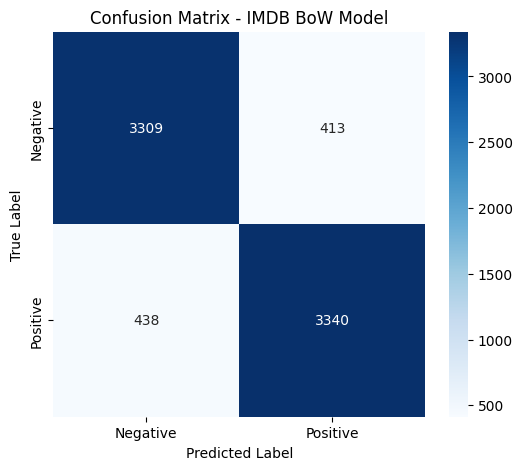

Confusion Matrix - IMDB LLaMa Model - Test Accuracy: 0.9485


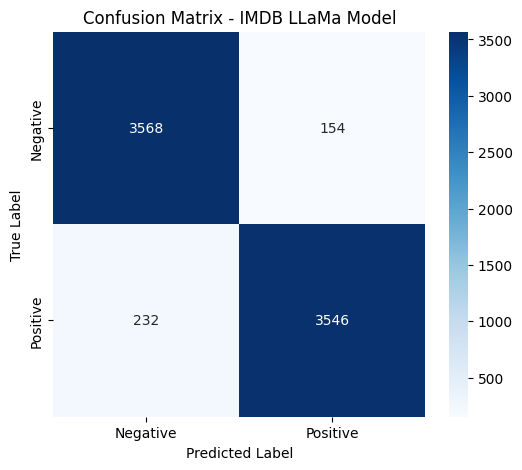

In [122]:
# Plot confusion matrices for final IMDB test set
plot_confusion_matrix(trained_model_bow_imdb, X_test_imdb_bow, y_test_imdb, title="Confusion Matrix - IMDB BoW Model")
plot_confusion_matrix(trained_model_llama_imdb, X_test_imdb_llama, y_test_imdb, title="Confusion Matrix - IMDB LLaMa Model")


In [118]:
!zip -r runs.zip runs

  adding: runs/ (stored 0%)
  adding: runs/bow_2/ (stored 0%)
  adding: runs/bow_2/events.out.tfevents.1742056424.22bd42a85ab5.31.9 (deflated 95%)
  adding: runs/bow_2/events.out.tfevents.1742056686.22bd42a85ab5.31.11 (deflated 95%)
  adding: runs/bow_2/events.out.tfevents.1742055642.22bd42a85ab5.31.2 (deflated 95%)
  adding: runs/llama/ (stored 0%)
  adding: runs/llama/events.out.tfevents.1742055831.22bd42a85ab5.31.4 (deflated 95%)
  adding: runs/llama/events.out.tfevents.1742055282.22bd42a85ab5.31.1 (deflated 95%)
  adding: runs/llama/events.out.tfevents.1742056348.22bd42a85ab5.31.8 (deflated 95%)
  adding: runs/bow/ (stored 0%)
  adding: runs/bow/events.out.tfevents.1742055256.22bd42a85ab5.31.0 (deflated 95%)
  adding: runs/bow/events.out.tfevents.1742056324.22bd42a85ab5.31.7 (deflated 95%)
  adding: runs/llama_2/ (stored 0%)
  adding: runs/llama_2/events.out.tfevents.1742055859.22bd42a85ab5.31.5 (deflated 95%)
  adding: runs/llama_2/events.out.tfevents.1742055901.22bd42a85ab5.31.6 